## Imports

In [18]:
import pandas as pd
import torch
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Construction du Graphe et Mapping des Identifiants

Cette étape transforme nos fichiers CSV en un graphe structuré pour PyTorch Geometric. Nous convertissons d'abord les identifiants des utilisateurs et des films en index continus (de 0 à N) pour qu'ils soient exploitables par les couches d'embeddings. Enfin, nous ne conservons que les notes supérieures ou égales à 4 pour définir des interactions positives, créant ainsi un objet HeteroData composé de deux types de nœuds distincts.

In [21]:
# Chemins vers les fichiers
ratings_path = '../data/ml-latest-small/ratings.csv'
movies_path = '../data/ml-latest-small/movies.csv'

# Chargement avec Pandas
ratings_df = pd.read_csv(ratings_path)
movies_df = pd.read_csv(movies_path)

# On crée des index de 0 à N pour les utilisateurs et les films
unique_user_id = ratings_df['userId'].unique()
user_mapping = {id: i for i, id in enumerate(unique_user_id)}

unique_movie_id = ratings_df['movieId'].unique()
movie_mapping = {id: i for i, id in enumerate(unique_movie_id)}

# Création du graphe PyTorch Geometric
data = HeteroData()

# On définit le nombre de nœuds
data['user'].num_nodes = len(unique_user_id)
data['movie'].num_nodes = len(unique_movie_id)

# On crée les arêtes (on ne garde que les bonnes notes >= 3.0)
mask = ratings_df['rating'] >= 3.0
edge_index_user = ratings_df[mask]['userId'].map(user_mapping).values
edge_index_movie = ratings_df[mask]['movieId'].map(movie_mapping).values

# Conversion en tenseurs PyTorch [2, num_edges]
data['user', 'rates', 'movie'].edge_index = torch.stack([
    torch.tensor(edge_index_user, dtype=torch.long),
    torch.tensor(edge_index_movie, dtype=torch.long)
], dim=0)

print(f"Structure du graphe : {data}")

Structure du graphe : HeteroData(
  user={ num_nodes=610 },
  movie={ num_nodes=9724 },
  (user, rates, movie)={ edge_index=[2, 81763] }
)


## Séparation des données en jeu d'entraînement, validation et test

Contrairement à un split classique, le **RandomLinkSplit** préserve la structure du graphe pour le "Message Passing" tout en cachant certaines arêtes (labels) que le modèle devra apprendre à prédire.

In [22]:
# On définit comment séparer les données (80% pour l'entraînement, 20% pour le reste)
transform = T.RandomLinkSplit(
    num_val=0.1,                  # 10% des données serviront à ajuster les hyperparamètres
    num_test=0.1,                 # 10% des données seront gardées pour l'évaluation finale
    disjoint_train_ratio=0.3,     # Sépare les arêtes de "message passing" (structure) des arêtes "labels" (cible)
    neg_sampling_ratio=1.0,       # Génère 1 exemple négatif (film non vu) pour chaque exemple positif
    add_negative_train_samples=False, # Les exemples négatifs sont créés à la volée pendant l'entraînement
    edge_types=('user', 'rates', 'movie'),        # Définit la relation source -> cible
    rev_edge_types=('movie', 'rev_rates', 'user'), # Définit la relation inverse (essentiel pour le GNN)
)

train_data, val_data, test_data = transform(data)

print(f"Nombre d'arêtes d'entraînement : {train_data['user', 'rates', 'movie'].edge_label_index.shape[1]}")
print(f"Nombre d'arêtes de test : {test_data['user', 'rates', 'movie'].edge_label_index.shape[1]}")

Nombre d'arêtes d'entraînement : 19623
Nombre d'arêtes de test : 16352


## Visualisation

/tmp/ipykernel_9829/4171831634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


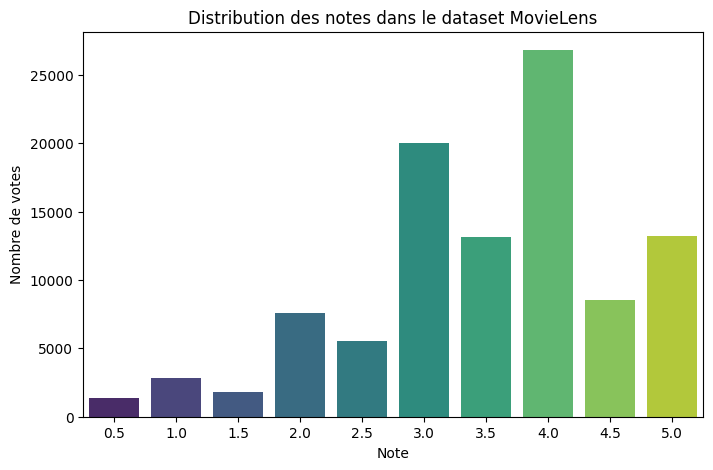

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution des notes dans le dataset MovieLens')
plt.xlabel('Note')
plt.ylabel('Nombre de votes')
plt.show()

Le graphique montre une forte tendance positive avec une concentration majeure des notes sur 3 et 4. Cette asymétrie indique que les utilisateurs notent principalement les films qu'ils ont appréciés, ce qui justifie notre choix de ne conserver que les notes supérieures ou égales à 3 pour modéliser des interactions de haute qualité.

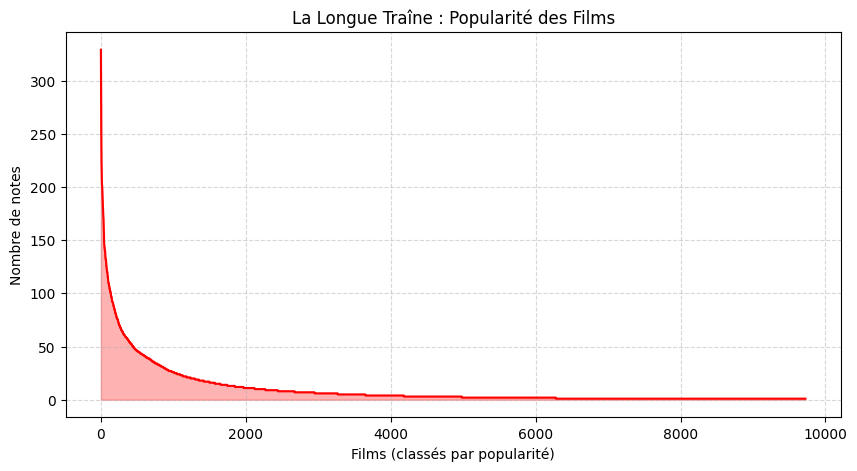

In [24]:
# Compter le nombre de notes par film
movie_counts = ratings_df.groupby('movieId').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(movie_counts)), movie_counts.values, color='red')
plt.fill_between(np.arange(len(movie_counts)), movie_counts.values, color='red', alpha=0.3)
plt.title('La Longue Traîne : Popularité des Films')
plt.xlabel('Films (classés par popularité)')
plt.ylabel('Nombre de notes')
plt.grid(ls='--', alpha=0.5)
plt.show()

On observe une chute brutale de la popularité : une poignée de blockbusters cumule l'essentiel des notes tandis que la grande majorité des films ne possède que très peu d'interactions. Cette structure rend la recommandation classique difficile pour les films moins connus et motive l'utilisation d'un GNN pour propager l'information via les relations entre utilisateurs.

In [25]:
n_users = ratings_df['userId'].nunique()
n_movies = ratings_df['movieId'].nunique()
n_ratings = len(ratings_df)

sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Nombre d'utilisateurs : {n_users}")
print(f"Nombre de films : {n_movies}")
print(f"Sparsité (vide) de la matrice : {sparsity * 100:.2f}%")

Nombre d'utilisateurs : 610
Nombre de films : 9724
Sparsité (vide) de la matrice : 98.30%


Avec une sparsité de 98.30%, la matrice est extrêmement creuse, signifiant qu'un utilisateur n'a noté qu'une infime fraction du catalogue total. Le défi du modèle sera de prédire les liens manquants malgré ce vide immense, en exploitant la connectivité du graphe pour déduire des préférences cachées.